# Visualization of Evaluation Results

This notebook visualizes the evaluation metrics of all trained models on the Ice Cream Dataset.  
It uses the detailed evaluation file `results/metrics/eval_results.csv`, which stores per-sample predictions and errors.

---

## 1. Aggregated Model Performance

We first compare all architectures globally based on their **Mean Squared Error (MSE)** and **Coefficient of Determination (R²)** across the entire test dataset.

Lower MSE and higher R² indicate better performance.

---

## 2. Performance vs. Input Complexity

Next, we analyze how model performance changes as the **number of traits** or **context factors** increases in the input.

These plots reveal how sensitive each architecture is to input complexity and whether certain models generalize better for richer contextual information.


✅ Loaded evaluation results from ../results/metrics/eval_results.csv


,sample_id,num_traits,num_context,total_tokens,y_true,Logistic Regression_pred,Logistic Regression_sq_error,Feedforward MLP_pred,Feedforward MLP_sq_error,Encoder Transformer_pred,Encoder Transformer_sq_error,Decoder Transformer_pred,Decoder Transformer_sq_error,Decision Tree_pred,Decision Tree_sq_error,Random Forest_pred,Random Forest_sq_error
0,0,2,2,4,0.30,0.386773,0.007530,0.288613,0.000130,0.284149,0.000251,0.258478,0.001724,0.437147,0.018809,0.299234,5.867504e-07
1,1,4,2,6,0.35,0.458586,0.011791,0.564649,0.046074,0.476290,0.015949,0.577779,0.051883,0.641439,0.084937,0.606271,6.567479e-02
2,2,5,1,6,0.15,0.191935,0.001759,0.227256,0.005969,0.179575,0.000875,0.165148,0.000229,0.293130,0.020486,0.260397,1.218750e-02
3,3,2,5,7,0.85,0.928287,0.006129,0.912238,0.003874,0.891181,0.001696,0.884898,0.001218,0.903502,0.002862,0.856131,3.759073e-05
4,4,2,5,7,0.30,0.281970,0.000325,0.321115,0.000446,0.320869,0.000436,0.296275,0.000014,0.283427,0.000275,0.293840,3.794069e-05


Detected models: ['Logistic Regression', 'Feedforward MLP', 'Encoder Transformer', 'Decoder Transformer', 'Decision Tree', 'Random Forest']


,Model,MSE,R2
3,Decoder Transformer,0.003187,0.947197
2,Encoder Transformer,0.006247,0.896510
1,Feedforward MLP,0.006697,0.889065
5,Random Forest,0.007560,0.874755
0,Logistic Regression,0.011513,0.809278
4,Decision Tree,0.012168,0.798419


📊 Saved MSE plot to ../results/plots/model_comparison_mse.png


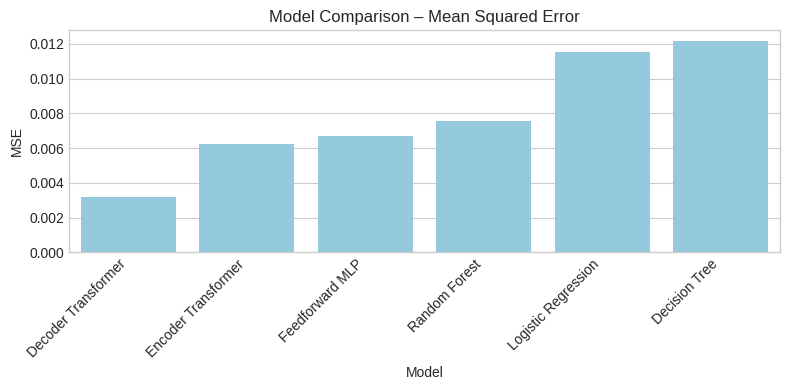

📊 Saved R² plot to ../results/plots/model_comparison_r2.png


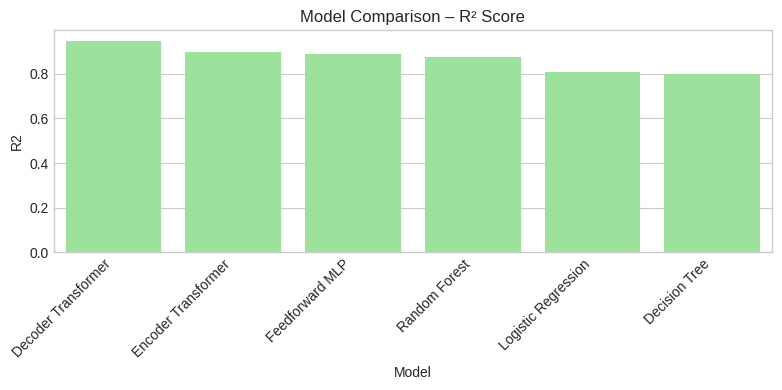

📊 Saved total input size plot to ../results/plots/mse_by_total_input_size.png


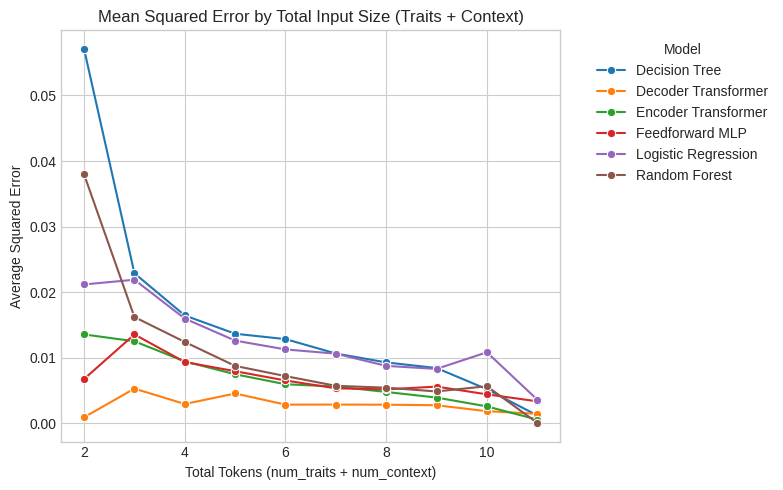

📊 Saved 3D plot for Logistic Regression to ../results/plots/3d_error_surface_Logistic_Regression.png
📊 Saved 3D plot for Feedforward MLP to ../results/plots/3d_error_surface_Feedforward_MLP.png
📊 Saved 3D plot for Encoder Transformer to ../results/plots/3d_error_surface_Encoder_Transformer.png
📊 Saved 3D plot for Decoder Transformer to ../results/plots/3d_error_surface_Decoder_Transformer.png
📊 Saved 3D plot for Decision Tree to ../results/plots/3d_error_surface_Decision_Tree.png
📊 Saved 3D plot for Random Forest to ../results/plots/3d_error_surface_Random_Forest.png


In [4]:
# VISUALIZATION OF MODEL EVALUATION RESULTS


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from mpl_toolkits.mplot3d import Axes3D

plt.style.use("seaborn-v0_8-whitegrid")
metrics_path = "../results/metrics/eval_results.csv"
plots_dir = "../results/plots"
os.makedirs(plots_dir, exist_ok=True)

# LOAD DATA

df = pd.read_csv(metrics_path)
print(f"✅ Loaded evaluation results from {metrics_path}")
display(df.head())

# Identify model columns
pred_cols = [c for c in df.columns if c.endswith("_pred")]
error_cols = [c for c in df.columns if c.endswith("_sq_error")]

meta_cols = ["sample_id", "num_traits", "num_context", "total_tokens", "y_true"]
models = [c.replace("_pred", "") for c in pred_cols]
print(f"Detected models: {models}")

# AGGREGATED MODEL PERFORMANCE

agg_data = []
for model in models:
    mse = df[f"{model}_sq_error"].mean()
    r2 = 1 - (df[f"{model}_sq_error"].sum() /
              ((df["y_true"] - df["y_true"].mean())**2).sum())
    agg_data.append({"Model": model, "MSE": mse, "R2": r2})

df_agg = pd.DataFrame(agg_data).sort_values(by="MSE")
display(df_agg)

# --- Plot MSE ---
plt.figure(figsize=(8,4))
sns.barplot(data=df_agg, x="Model", y="MSE", color="skyblue")
plt.title("Model Comparison – Mean Squared Error")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
mse_path = os.path.join(plots_dir, "model_comparison_mse.png")
plt.savefig(mse_path, dpi=300, bbox_inches="tight")
print(f"📊 Saved MSE plot to {mse_path}")
plt.show()

# --- Plot R² ---
plt.figure(figsize=(8,4))
sns.barplot(data=df_agg, x="Model", y="R2", color="lightgreen")
plt.title("Model Comparison – R² Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
r2_path = os.path.join(plots_dir, "model_comparison_r2.png")
plt.savefig(r2_path, dpi=300, bbox_inches="tight")
print(f"📊 Saved R² plot to {r2_path}")
plt.show()

# PERFORMANCE VS TOTAL INPUT SIZE (TRAITS + CONTEXT)

df_long = df.melt(
    id_vars=["num_traits", "num_context", "total_tokens"],
    value_vars=[c for c in df.columns if c.endswith("_sq_error")],
    var_name="Model",
    value_name="Squared Error"
)
df_long["Model"] = df_long["Model"].str.replace("_sq_error", "")

plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_long.groupby(["total_tokens", "Model"])["Squared Error"].mean().reset_index(),
    x="total_tokens", y="Squared Error", hue="Model", marker="o"
)
plt.title("Mean Squared Error by Total Input Size (Traits + Context)")
plt.xlabel("Total Tokens (num_traits + num_context)")
plt.ylabel("Average Squared Error")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
total_path = os.path.join(plots_dir, "mse_by_total_input_size.png")
plt.savefig(total_path, dpi=300, bbox_inches="tight")
print(f"📊 Saved total input size plot to {total_path}")
plt.show()

# 3D VISUALIZATION: TRAITS vs CONTEXT vs ERROR

from mpl_toolkits.mplot3d import Axes3D

for model_name in models:
    temp = df_long[df_long["Model"] == model_name]
    pivot_data = (
        temp.groupby(["num_traits", "num_context"])["Squared Error"]
        .mean()
        .reset_index()
    )

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        pivot_data["num_traits"],
        pivot_data["num_context"],
        pivot_data["Squared Error"],
        c=pivot_data["Squared Error"],
        cmap="viridis",
        s=60
    )

    ax.set_xlabel("Number of Traits")
    ax.set_ylabel("Number of Context Factors")
    ax.set_zlabel("Mean Squared Error")
    ax.set_title(f"3D Error Surface – {model_name}")

    plt.tight_layout()
    three_d_path = os.path.join(plots_dir, f"3d_error_surface_{model_name.replace(' ', '_')}.png")
    plt.savefig(three_d_path, dpi=300, bbox_inches="tight")
    print(f"📊 Saved 3D plot for {model_name} to {three_d_path}")
    plt.close(fig)  # optional: schließt Figure, um Speicher zu sparen
